# <font color=#0099CC>**RNN (LSTM): V_in = 30, V_out = 30**</font>

## <font color=#0099CC>**0. INTRODUCCIÓN**</font>

### <font color=#336699>**0.1. Objetivo de este cuaderno**</font>

Notebook individual para una única combinación del grid 4×4 (**V_in=30**, **V_out=30**). Patrón «1 notebook = 1 combo»: se entrena un modelo **RNN (LSTM)** con esa pareja de ventanas y se persiste mediante `BestRunTracker` (callback compartido) la **mejor ejecución histórica** del combo + la última, junto con la curva de entrenamiento. El consolidado de los 16 parciales y los heatmaps los genera `_agregador_rnn.ipynb`.

Los datos son **log-retornos** multivariantes (23 activos); el MAE se interpreta en esa escala. En esta combinación activamos el escalado `scaler='standard'` (fit **solo** sobre `X_tr`, transform a val/test). La curva incluye como referencia los MAE de los 3 baselines (`buy_and_hold`, `trivial`, `lineal`) para el mismo `(v_in, v_out)`.

**Salidas generadas**:
- `08_results/runs/rnn/rnn_vin30_vout30/best.keras` — pesos+arquitectura de la mejor ejecución histórica
- `08_results/runs/rnn/rnn_vin30_vout30/best.json` — hparams + MAEs + epoch + timestamp del best
- `08_results/runs/rnn/rnn_vin30_vout30/last.json` — última ejecución (auditoría)
- `08_results/runs/rnn/rnn_vin30_vout30/history.csv` — append-only (1 fila por ejecución)
- `08_results/tablas/parciales/rnn_vin30_vout30.csv` — escrito desde best.json (mejor histórica)
- `08_results/curvas/rnn/rnn_vin30_vout30.png` — curva con baselines superpuestos

La partición train/val/test es cronológica con semilla fija (`random_state=42`): **no modificar**. Para otra combinación: duplicar este notebook y cambiar **solo** `V_IN` y `V_OUT` en la sección de configuración.

## <font color=#0099CC>**1. ENTORNO DE EJECUCIÓN**</font>

### <font color=#336699>**1.1. Detección Colab / local y rutas del proyecto**</font>

Se configura `BASE`, el acceso a Drive cuando aplica y el `sys.path` para importar utilidades compartidas sin duplicar código.

In [ ]:
import os, sys

def detect_env():
    try:
        import google.colab
        return 'colab'
    except ImportError:
        return 'local'

ENV = detect_env()

if ENV == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/Taller4_DL_MIAX'
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))

SRC = os.path.join(BASE, '01_src_compartido')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

print(f'> Entorno : {ENV}')
print(f'> BASE    : {BASE}')
print(f'> SRC     : {SRC}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
> Entorno : colab
> BASE    : /content/drive/MyDrive/Taller4_DL_MIAX
> SRC     : /content/drive/MyDrive/Taller4_DL_MIAX/01_src_compartido


## <font color=#0099CC>**2. IMPORTACIONES**</font>

### <font color=#336699>**2.1. Librerías y módulos compartidos**</font>

Stack numérico, TensorFlow/Keras y utilidades de datos y métricas; se inyecta `BASE` en `metrics_utils` antes de cualquier guardado.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from dataset_utils import load_data, create_dataset, get_partitions, TICKERS
import metrics_utils
metrics_utils.BASE_DRIVE = BASE
from metrics_utils import (
    plot_curva,
    BestRunTracker,
    resumen_vs_baselines,
    cargar_best_modelo,
)

print(f'> TensorFlow : {tf.__version__}')
print(f'> GPU        : {tf.config.list_physical_devices("GPU")}')

> TensorFlow : 2.20.0
> GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## <font color=#0099CC>**3. CONFIGURACIÓN DEL EXPERIMENTO**</font>

### <font color=#336699>**3.1. Combinación de ventanas e hiperparámetros**</font>

Única celda que cambia al duplicar el notebook para otro par **V_in / V_out**.

In [ ]:
MODELO = 'rnn'
V_IN, V_OUT = 30, 30

EPOCHS     = 5000
BATCH_SIZE = 32
PATIENCE   = 500

SCALER = 'standard'   # None | 'standard' | 'minmax'  — fit SOLO sobre X_tr

print(f'> Combinación: V_in={V_IN}, V_out={V_OUT}')
print(f'> Scaler    : {SCALER}')

> Combinación: V_in=30, V_out=30
> Scaler    : standard


## <font color=#0099CC>**4. DESCARGA DE DATOS**</font>

### <font color=#336699>**4.1. Serie multivariante y construcción del dataset**</font>

Precios de cierre ajustados de los 23 activos (vía `yfinance`), transformados a log-retornos. Se construyen las ventanas para esta combinación y se particiona cronológicamente (semilla competición = 42). El scaler se ajusta exclusivamente con los datos de entrenamiento y se aplica con `transform` a val/test (sin data-leakage). `Y` se deja sin escalar.

In [ ]:
data, df = load_data()
print(f'> Datos : {data.shape[0]:,} días × {data.shape[1]} activos')
print(f'> Rango : {df.index[0].date()} → {df.index[-1].date()}')

X, Y = create_dataset(data, V_IN, V_OUT)
X_tr, X_val, X_test, Y_tr, Y_val, Y_test, sc = get_partitions(
    X, Y, scaler=SCALER, return_scaler=True, verbose=True, val_size= 0.2
)

print(f'> X shape: {X.shape}   Y shape: {Y.shape}')
print(f'> Train: {X_tr.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test.shape[0]:,}')
if sc is not None:
    print(f'> Scaler: {type(sc).__name__} fitted on X_tr only')
    print(f'>   mean(X_tr_scaled) ≈ {X_tr.mean():+.4f}   std(X_tr_scaled) ≈ {X_tr.std():.4f}')

> Datos : 16,200 días × 23 activos
> Rango : 1962-01-03 → 2026-05-15


> Scaler: standard fitted on X_tr only — applied to train/val/test
> Particiones — Train:  11620  Val:   2906  Test:   1615
> X shape: (16141, 30, 23)   Y shape: (16141, 23)
> Train: 11,620  Val: 2,906  Test: 1,615
> Scaler: StandardScaler fitted on X_tr only
>   mean(X_tr_scaled) ≈ +0.0000   std(X_tr_scaled) ≈ 1.0000


## <font color=#0099CC>**5. MODELO RNN (LSTM)**</font>

### <font color=#336699>**5.1. Arquitectura y compilación**</font>

Dos capas LSTM apiladas (128 → 64 unidades, `return_sequences=True` en la primera) con `BatchNormalization` + `Dropout(0.25)` y cabezal denso (96 unidades, relu + Dropout 0.35). Loss: `mae`.

In [ ]:
N_ASSETS = len(TICKERS)  # 23

l2 = regularizers.l2(1e-4)

model = models.Sequential([
    layers.LSTM(128, input_shape=(V_IN, N_ASSETS), return_sequences=True),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    layers.LSTM(64, return_sequences=False),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    layers.Dense(96, activation='relu', kernel_regularizer=l2),
    layers.Dropout(0.35),

    layers.Dense(N_ASSETS),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='mae',
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        77,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 96)             │         6,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │         2,231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,471 (533.09 KB)

 Trainable params: 136,087 (531.59 KB)

 Non-trainable params: 384 (1.50 KB)

## <font color=#0099CC>**6. ENTRENAMIENTO**</font>

### <font color=#336699>**6.1. Ajuste con callbacks**</font>

`EarlyStopping` con `restore_best_weights`, `ReduceLROnPlateau` cuando `val_loss` se estanca y `BestRunTracker`, que durante el fit guarda en `best.keras` la mejor época y al terminar:
- escribe siempre `last.json` (última ejecución),
- si la `mae_val` mejora la histórica del combo, pisa `best.json` y el CSV parcial,
- añade una fila a `history.csv` (append-only).

Si la nueva ejecución no mejora, el `best.keras` previo se restaura intacto.

In [ ]:
es = EarlyStopping(
    monitor='val_loss', patience=PATIENCE,
    restore_best_weights=True, verbose=1,
)

rlr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.8, patience=20,
    min_lr=1e-6, verbose=1,
)

tracker = BestRunTracker(
    MODELO, V_IN, V_OUT,
    datasets=(X_tr, Y_tr, X_val, Y_val, X_test, Y_test), auto_plot=True,
    hparams_extra={
        'batch_size': BATCH_SIZE,
        'patience':   PATIENCE,
        'epochs_max': EPOCHS,
        'scaler':     SCALER,
    },
)

history = model.fit(
    X_tr, Y_tr,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es, rlr, tracker],
    verbose=2,
)

print(f'> Epochs entrenadas: {len(history.history["loss"])}')
print(f'> Best val_loss   : {min(history.history["val_loss"]):.5f}')

## <font color=#0099CC>**7. MÉTRICAS Y PERSISTENCIA**</font>

### <font color=#336699>**7.1. MAE por partición y comparativa con baselines**</font>

`BestRunTracker` ya ha persistido el `best.keras`, `best.json`, `last.json`, `history.csv` y el CSV parcial (este último siempre con la mejor histórica). Aquí solo:
- dibujamos la curva de entrenamiento con líneas horizontales de los 3 baselines como referencia,
- imprimimos la comparativa MAE modelo-vs-baselines del combo.

`_agregador_rnn.ipynb` consolidará los 16 parciales en `rnn_resultados.csv` y generará los heatmaps.

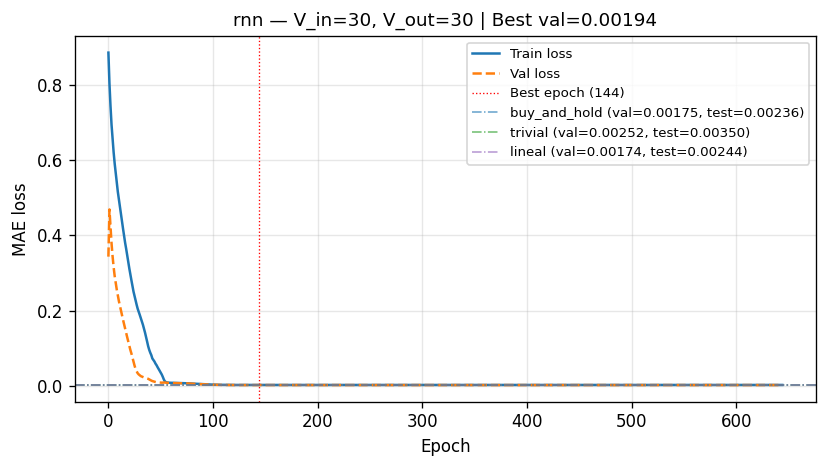

> Comparativa MAE — V_in=30, V_out=30


baseline,n_params,mae_train,mae_val,mae_test,mejora_test_%
rnn,—,0.00220,0.00194,0.00234,—
buy_and_hold,0,0.00225,0.00175,0.00236,+0.58%
trivial,0,0.00318,0.00252,0.00350,+33.01%
lineal,"15,893",0.00215,0.00174,0.00244,+3.84%



> MAE  train=0.0022  val=0.0019  test=0.0023  params=136,471
> Artefactos en: 08_results/runs/rnn/rnn_vin30_vout30/


In [ ]:
maes = tracker.maes_last  # MAE train/val/test del best.keras de esta ejecución

plot_curva(history, MODELO, V_IN, V_OUT, mostrar_baselines=True, save=tracker.improved)
plt.show()

resumen_vs_baselines(maes, V_IN, V_OUT, nombre_modelo=MODELO)

print(f'\n> MAE  train={maes["train"]:.4f}  val={maes["val"]:.4f}  test={maes["test"]:.4f}'
      f'  params={model.count_params():,}')
print(f'> Artefactos en: 08_results/runs/{MODELO}/{MODELO}_vin{V_IN}_vout{V_OUT}/')

## <font color=#0099CC>**8. CONSOLIDACIÓN 4×4**</font>

### <font color=#336699>**8.1. Heatmaps y tabla global**</font>

Los mapas de calor MAE y la tabla completa del modelo **RNN (LSTM)** sobre todas las combinaciones no se generan aquí; ejecutar `_agregador_rnn.ipynb` cuando existan los 16 CSV parciales.